# Duelo Final — XGBoost com Otimização Bayesiana (Optuna)
### Competição Titanic | Kaggle

**Modelo escolhido:** XGBoost (eXtreme Gradient Boosting)

**Principal inovação em relação à aula:**
A aula utilizou `GridSearchCV` para otimizar o XGBoost. Aqui vamos um passo além,
usando **Optuna**, framework de otimização bayesiana que aprende, a cada tentativa,
quais regiões do espaço de hiperparâmetros têm mais chance de gerar bons resultados.
Isso é mais inteligente do que testar combinações aleatórias ou em grade.

**Estratégia completa:**
- Feature engineering avançado (Title, FamilySize, IsAlone, FarePerPerson)
- EDA orientada a decisões de modelagem
- SMOTE + StandardScaler no pré-processamento
- Optuna com 100 trials para otimização bayesiana dos hiperparâmetros
- StratifiedKFold para validação cruzada robusta
- Curva ROC, AUC e análise de importância das features

## 1. Importação das Bibliotecas

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Modelo principal
import xgboost as xgb
from xgboost import XGBClassifier

# Otimização bayesiana
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suprime logs intermediários

# Validação
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

# Reprodutibilidade
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print('Bibliotecas importadas com sucesso!')
print(f'XGBoost versão: {xgb.__version__}')
print(f'Optuna versão:  {optuna.__version__}')

Bibliotecas importadas com sucesso!
XGBoost versão: 3.2.0
Optuna versão:  4.8.0


c:\Users\Rafael\Dev\ciencia_de_dados_v2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carregamento dos Dados

In [2]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f'Treino: {train_df.shape[0]} linhas x {train_df.shape[1]} colunas')
print(f'Teste:  {test_df.shape[0]} linhas x {test_df.shape[1]} colunas')

Treino: 891 linhas x 12 colunas
Teste:  418 linhas x 11 colunas


In [3]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Verificando valores nulos
print('Valores nulos — Treino:')
print(train_df.isnull().sum())
print()
print('Valores nulos — Teste:')
print(test_df.isnull().sum())

Valores nulos — Treino:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Valores nulos — Teste:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [5]:
# Distribuição da variável alvo
print('Distribuição da variável alvo (Survived):')
print(train_df['Survived'].value_counts())

print(f'Taxa de sobrevivência: {train_df["Survived"].mean():.2%}')

Distribuição da variável alvo (Survived):
Survived
0    549
1    342
Name: count, dtype: int64
Taxa de sobrevivência: 38.38%


**Observação**: classes desbalanceadas (62% x 38%) — trataremos com SMOTE.

## 3. Análise Exploratória dos Dados (EDA)

Antes de modelar, precisamos entender os dados. A EDA não é uma etapa decorativa,
ela orienta diretamente as decisões de feature engineering e pré-processamento.
Cada gráfico abaixo responde uma pergunta específica que guiará qualquer modelo.

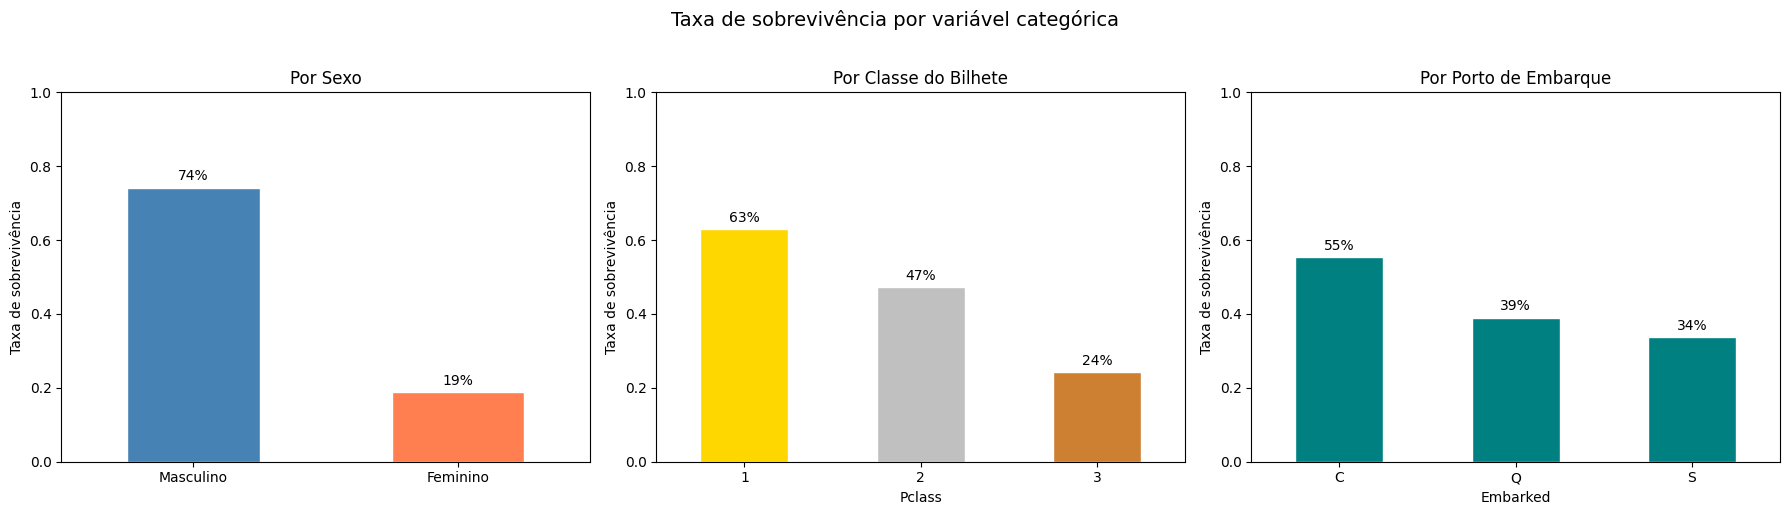

In [6]:
# Taxa de sobrevivência pelas principais variáveis categóricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Taxa de sobrevivência por variável categórica', fontsize=14, y=1.02)

# Por Sexo
survival_sex = train_df.groupby('Sex')['Survived'].mean()
survival_sex.index = ['Masculino', 'Feminino']
survival_sex.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Por Sexo')
axes[0].set_ylabel('Taxa de sobrevivência')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0%}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.02), ha='center')

# Por Classe
survival_pclass = train_df.groupby('Pclass')['Survived'].mean()
survival_pclass.plot(kind='bar', ax=axes[1], color=['gold', 'silver', '#cd7f32'], edgecolor='white')
axes[1].set_title('Por Classe do Bilhete')
axes[1].set_ylabel('Taxa de sobrevivência')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0%}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.02), ha='center')

# Por Porto de Embarque
survival_embarked = train_df.groupby('Embarked')['Survived'].mean()
survival_embarked.plot(kind='bar', ax=axes[2], color='teal', edgecolor='white')
axes[2].set_title('Por Porto de Embarque')
axes[2].set_ylabel('Taxa de sobrevivência')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=0)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.0%}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.02), ha='center')

plt.tight_layout()
plt.show()

**Insights sobre variáveis categoricas:**
- Mulheres sobreviveram mais do que homens (74% vs 19%). nesse contexto, sexo será feature essencial.
- 1ª classe: 63% de sobrevivência vs 24% na 3ª. Pclass tem alto poder preditivo.
- Porto C (Cherbourg) tem maior taxa de sobrevivência. Isso pode refletir perfil socioeconômico.

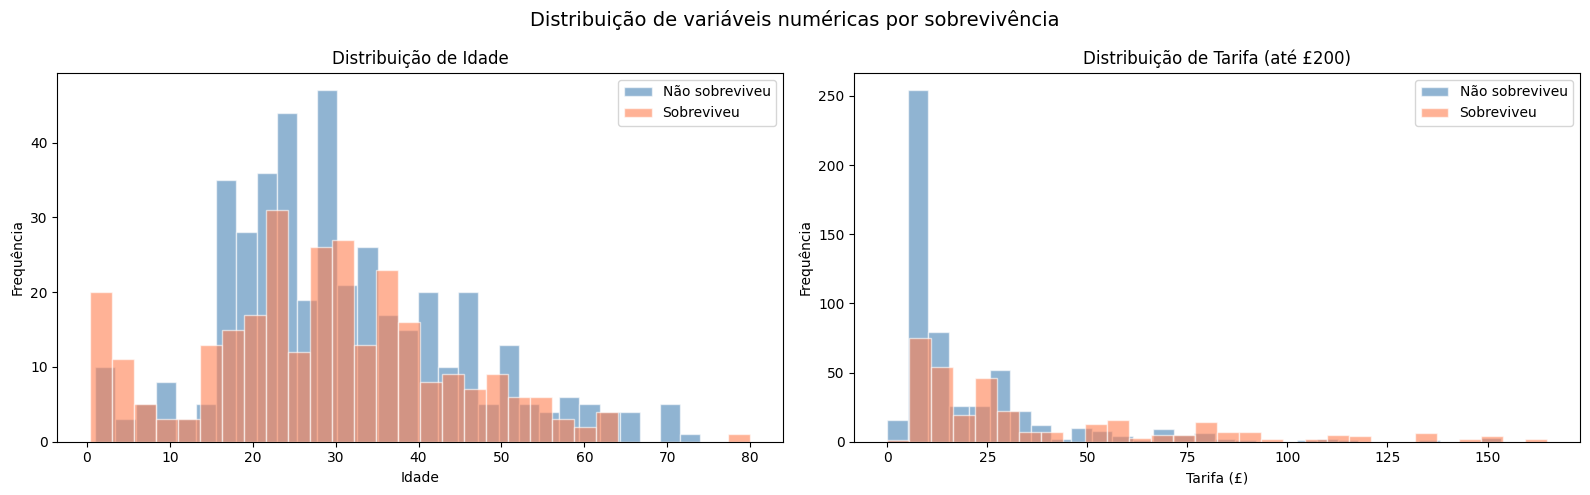

In [7]:
# Distribuição de Idade e Tarifa entre sobreviventes e não sobreviventes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribuição de variáveis numéricas por sobrevivência', fontsize=14)

for survived, label, color in [(0, 'Não sobreviveu', 'steelblue'), (1, 'Sobreviveu', 'coral')]:
    subset = train_df[train_df['Survived'] == survived]['Age'].dropna()
    axes[0].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0].set_title('Distribuição de Idade')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')
axes[0].legend()

for survived, label, color in [(0, 'Não sobreviveu', 'steelblue'), (1, 'Sobreviveu', 'coral')]:
    subset = train_df[(train_df['Survived'] == survived) & (train_df['Fare'] < 200)]['Fare']
    axes[1].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
axes[1].set_title('Distribuição de Tarifa (até £200)')
axes[1].set_xlabel('Tarifa (£)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

insights sobre variavis númericas:
- Crianças menores de 10 anos, tiveram maior chance de sobrevivência.
- Tarifas mais altas (Considerados de 1ª classe) estão fortemente associadas à sobrevivência.
- Com essa informação, é justificado criar categoria FarePerPerson — normaliza pela família, não só pelo indivíduo.

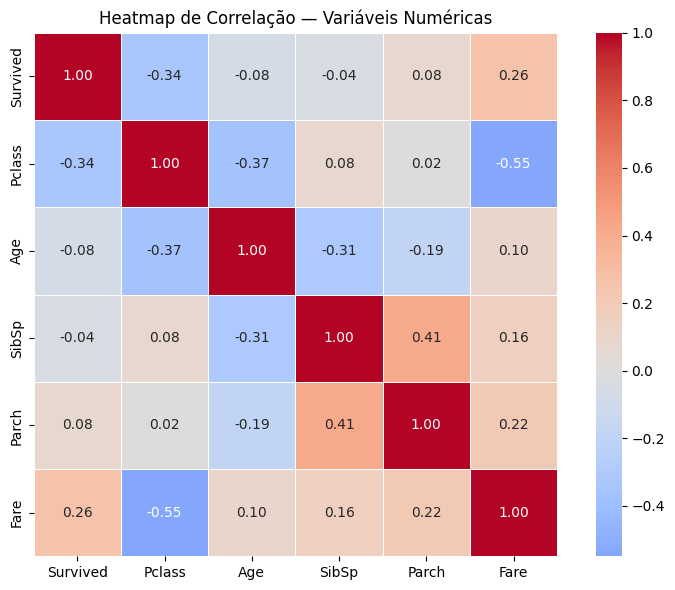

Pclass   -0.338
Fare      0.257
Parch     0.082
Age      -0.077
SibSp    -0.035
Name: Survived, dtype: float64


In [8]:
# Heatmap de correlação
colunas_numericas = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = train_df[colunas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5
)
plt.title('Heatmap de Correlação — Variáveis Numéricas')
plt.tight_layout()
plt.show()

print(corr['Survived'].drop('Survived').sort_values(key=abs, ascending=False).round(3))


**Principais correlações com Survived:**

- `Pclass`: correlação negativa (-0.34) — quanto maior a classe, menor a sobrevivência.
- `Fare`: correlação positiva (0.26) — tarifas mais altas = mais sobreviventes.
- `SibSp/Parch` isolados têm baixa correlação — isso motiva criar FamilySize combinado.

## 4. Feature Engineering

A EDA acima orientou diretamente as features que vamos criar.
A aula usou apenas 4 variáveis (`Sex`, `Cabin_known`, `Fare`, `Pclass`).
Aqui usaremos 14 — incluindo 4 features novas construídas a partir dos dados brutos.

**Raciocínio por feature nova:**
- `Title`: o título social captura ao mesmo tempo gênero, faixa etária e status social
  em uma única variável — mais informativo do que `Sex` isolado
- `FamilySize`: SibSp e Parch isolados têm baixa correlação com Survived;
  combinados em uma única feature, capturam melhor o impacto de viajar em família
- `IsAlone`: passageiros sozinhos tiveram padrão de sobrevivência variável
- `FarePerPerson`: normaliza a tarifa pelo tamanho da família, refletindo
  melhor o poder aquisitivo real do passageiro

In [9]:
# Levantamento de todos os títulos presentes nos dados
# — necessário antes de decidir quais agrupar como 'Rare'
#
# Regex utilizado: r',\s(?:the\s+)?([A-Za-z]+)\.'
# O trecho (?:the\s+)? é um grupo não-capturante opcional que ignora
# o artigo 'the' presente em nomes como 'Rothes, the Countess.'
# Sem isso, o regex capturaria 'the' em vez de 'Countess',
# gerando um título desconhecido que seria mapeado como 0.

regex_titulo = r',\s(?:the\s+)?([A-Za-z]+)\.'

titulos_treino = train_df['Name'].str.extract(regex_titulo)[0].value_counts()
titulos_teste  = test_df['Name'].str.extract(regex_titulo)[0].value_counts()

print('=== Títulos encontrados no TREINO ===')
print(titulos_treino)
print()
print('=== Títulos encontrados no TESTE ===')

=== Títulos encontrados no TREINO ===
0
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

=== Títulos encontrados no TESTE ===


In [10]:
# Taxa de sobrevivência por título, para definir quais manter e quais agrupar
train_df['Title_temp'] = train_df['Name'].str.extract(r',\s([A-Za-z]+)\.')

analise_titulos = (
    train_df.groupby('Title_temp')['Survived']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'taxa_sobrevivencia', 'count': 'total'})
    .sort_values('total', ascending=False)
)
analise_titulos['taxa_sobrevivencia'] = analise_titulos['taxa_sobrevivencia'].round(2)

print('=== Taxa de sobrevivência por título ===')
print(analise_titulos)
print()
print('Critério: títulos com menos de 10 ocorrências → agrupados como Rare.')
raros = analise_titulos[analise_titulos['total'] < 10].index.tolist()
print(f'Títulos Rare: {raros}')

train_df.drop(columns=['Title_temp'], inplace=True)

=== Taxa de sobrevivência por título ===
            taxa_sobrevivencia  total
Title_temp                           
Mr                        0.16    517
Miss                      0.70    182
Mrs                       0.79    125
Master                    0.57     40
Dr                        0.43      7
Rev                       0.00      6
Major                     0.50      2
Col                       0.50      2
Mlle                      1.00      2
Lady                      1.00      1
Capt                      0.00      1
Don                       0.00      1
Jonkheer                  0.00      1
Mme                       1.00      1
Ms                        1.00      1
Sir                       1.00      1

Critério: títulos com menos de 10 ocorrências → agrupados como Rare.
Títulos Rare: ['Dr', 'Rev', 'Major', 'Col', 'Mlle', 'Lady', 'Capt', 'Don', 'Jonkheer', 'Mme', 'Ms', 'Sir']


In [11]:
def criar_features(df):
    """
    Aplica todas as transformações de feature engineering.
    Recebe um DataFrame e retorna o mesmo com novas colunas.
    """
    df = df.copy()

    # --- Título social extraído do Nome ---
    # A maioria dos nomes segue o formato: 'Sobrenome, Titulo. Nome'
    # Exceção identificada: 'Rothes, the Countess. of (...)'
    # O regex original capturava 'the' (artigo) em vez de 'Countess',
    # pois 'the' vem antes do ponto e satisfazia o padrão anterior.
    # O regex corrigido usa (?:the\s+)? para ignorar o artigo quando presente.
    df['Title'] = df['Name'].str.extract(r',\s(?:the\s+)?([A-Za-z]+)\.')

    # Títulos raros: menos de 10 ocorrências no treino (análise acima).
    # Dona incluída pois aparece no teste mas não no treino.
    # Mantidos como categoria própria: Mr, Miss, Mrs, Master (40+ ocorrências cada).
    titulos_raros = ['Dona', 'Lady', 'Countess', 'Capt', 'Col', 'Don',
                     'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Mlle', 'Ms', 'Mme']
    df['Title'] = df['Title'].replace(titulos_raros, 'Rare')
    mapa_titulos = {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5}
    df['Title'] = df['Title'].map(mapa_titulos).fillna(0).astype(int)

    # --- Tamanho da Família ---
    # SibSp + Parch isolados têm baixa correlação; combinados capturam melhor o padrão
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 = o próprio passageiro

    # --- Indicador de viajante solo ---
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # --- Tarifa por pessoa ---
    # Normaliza pelo tamanho da família — reflete melhor o poder aquisitivo real
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']

    # --- Cabine conhecida ou não ---
    df['Cabin_known'] = df['Cabin'].notna().astype(int)

    return df


train_df = criar_features(train_df)
test_df  = criar_features(test_df)

print('Feature engineering aplicado!')
print()
print('Distribuição dos títulos após agrupamento:')
print(train_df['Title'].value_counts().sort_index())
print('(1=Mr, 2=Miss, 3=Mrs, 4=Master, 5=Rare)')
print()
print(f'Registros com Title == 0 (erro): {(train_df["Title"] == 0).sum()}')
print('Esperado: 0')

Feature engineering aplicado!

Distribuição dos títulos após agrupamento:
Title
1    517
2    182
3    125
4     40
5     27
Name: count, dtype: int64
(1=Mr, 2=Miss, 3=Mrs, 4=Master, 5=Rare)

Registros com Title == 0 (erro): 0
Esperado: 0


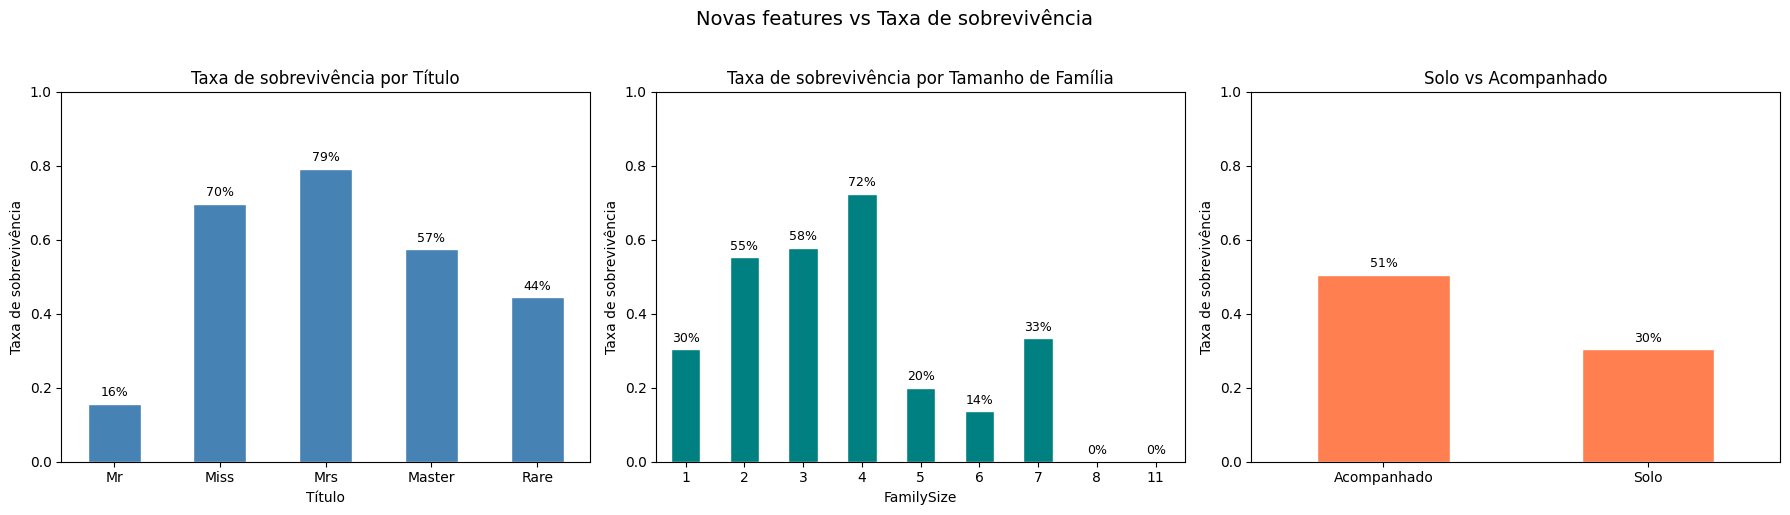

In [12]:
# Visualizando as novas features em relação à sobrevivência
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Novas features vs Taxa de sobrevivência', fontsize=14, y=1.02)

# Por Título — usando rótulos textuais no eixo X em vez dos códigos numéricos
# Isso evita confusão: o leitor vê 'Mr', 'Miss', etc. em vez de 1, 2, 3...
mapa_reverso = {1: 'Mr', 2: 'Miss', 3: 'Mrs', 4: 'Master', 5: 'Rare'}
title_data = (
    train_df.groupby('Title')['Survived']
    .mean()
    .rename(index=mapa_reverso)  # converte 1→Mr, 2→Miss, etc.
)
title_data.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Taxa de sobrevivência por Título')
axes[0].set_xlabel('Título')
axes[0].set_ylabel('Taxa de sobrevivência')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0%}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.02),
                     ha='center', fontsize=9)

# Por FamilySize
family_survival = train_df.groupby('FamilySize')['Survived'].mean()
family_survival.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Taxa de sobrevivência por Tamanho de Família')
axes[1].set_xlabel('FamilySize')
axes[1].set_ylabel('Taxa de sobrevivência')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0%}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.02),
                     ha='center', fontsize=9)

# IsAlone
alone_survival = train_df.groupby('IsAlone')['Survived'].mean()
alone_survival.index = ['Acompanhado', 'Solo']
alone_survival.plot(kind='bar', ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title('Solo vs Acompanhado')
axes[2].set_xlabel('')
axes[2].set_ylabel('Taxa de sobrevivência')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=0)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.0%}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.02),
                     ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Insights das novas features:**
- Título:
  - Mrs (casadas) e Miss têm as maiores taxas de sobrevivência (79% e 70%)
  - Mr (homens adultos) têm apenas 16% — o maior grupo e o mais penalizado
  - Master (crianças masculinas) sobreviveram mais que Mr adultos (57%)
  - Isso confirma que Title captura padrões que Sex isolado não consegue
- Tamanho de Família:
  - Famílias pequenas (2 a 4 pessoas) tiveram as maiores taxas de sobrevivência (55% a 72%)
  - Viajar sozinho (FamilySize=1) ou em grupo grande (7+) reduziu as chances
  - Famílias muito grandes podem ter tido dificuldade de se organizar na evacuação
- Solo vs Acompanhado:
  - Passageiros acompanhados sobreviveram mais (cerca de 51%) do que os sozinhos (30%)
  - Isso valida criar IsAlone como feature pois torna-se padrão é claro e consistente

## 5. Pré-processamento dos Dados

Com a EDA e o feature engineering concluídos, preparamos os dados para o modelo.

**Codificação de variáveis categóricas:**
- `Sex`: dois valores → **Label Encoding** (0/1)
- `Embarked`: três valores → **One-Hot Encoding** para evitar
  que o modelo interprete uma ordenação inexistente entre portos

**Imputação de valores nulos:**
Usamos a **mediana por grupo** (Pclass + Sex) em vez da média global.
A distribuição etária varia muito entre classes sociais — uma média global
mascararia essa diferença e introduziria ruído desnecessário.

**Seleção de features:**
14 variáveis no total, incluindo todas as novas features criadas na etapa anterior.

In [13]:
# Codificação de variáveis categóricas
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
test_df['Sex']  = test_df['Sex'].map({'male': 0, 'female': 1})

train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked')
test_df  = pd.get_dummies(test_df,  columns=['Embarked'], prefix='Embarked')

# Garantindo que colunas Embarked existam em ambos os datasets
for col in ['Embarked_C', 'Embarked_Q', 'Embarked_S']:
    if col not in test_df.columns:
        test_df[col] = 0

print('Codificação aplicada!')

Codificação aplicada!


In [14]:
# Imputação de valores nulos por grupo (Pclass + Sex)
for df in [train_df, test_df]:
    df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
        lambda x: x.fillna(x.median())
    )

# Fare: 1 nulo no teste — mediana por Pclass
test_df['Fare'] = test_df.groupby('Pclass')['Fare'].transform(
    lambda x: x.fillna(x.median())
)

# Recalculando FarePerPerson após imputação
train_df['FarePerPerson'] = train_df['Fare'] / train_df['FamilySize']
test_df['FarePerPerson']  = test_df['Fare']  / test_df['FamilySize']

print('Imputação concluída!')
print(f'Nulos restantes — Treino: {train_df.isnull().sum().sum()}')
print(f'Nulos restantes — Teste:  {test_df.isnull().sum().sum()}')

Imputação concluída!
Nulos restantes — Treino: 687
Nulos restantes — Teste:  327


In [15]:
# Definição das features
FEATURES = [
    'Pclass',         # Classe do bilhete
    'Sex',            # Gênero
    'Age',            # Idade (imputação inteligente por grupo)
    'SibSp',          # Irmãos/cônjuge
    'Parch',          # Pais/filhos
    'Fare',           # Tarifa
    'Cabin_known',    # Cabine conhecida?
    'Title',          # Título social (NOVO)
    'FamilySize',     # Tamanho da família (NOVO)
    'IsAlone',        # Viajando sozinho? (NOVO)
    'FarePerPerson',  # Tarifa por pessoa (NOVO)
    'Embarked_C',
    'Embarked_Q',
    'Embarked_S',
]

X      = train_df[FEATURES]
y      = train_df['Survived']
X_test = test_df[FEATURES]

print(f'Features utilizadas: {len(FEATURES)}')
print(f'Shape X treino: {X.shape}')
print(f'Shape X teste:  {X_test.shape}')

Features utilizadas: 14
Shape X treino: (891, 14)
Shape X teste:  (418, 14)


## 6. Balanceamento e Padronização

**Por que balancear?**
O treino tem 549 não sobreviventes (62%) contra 342 sobreviventes (38%).
Sem correção, o modelo aprende a prever sempre a classe majoritária —
o que garante boa acurácia mas péssimo recall na classe minoritária.
O **SMOTE** resolve isso gerando amostras sintéticas da classe minoritária,
sem descartar dados reais como faria o undersampling.

**Por que padronizar com XGBoost?**
O XGBoost é baseado em árvores e tecnicamente não precisa de padronização.
No entanto, padronizar torna os hiperparâmetros como `learning_rate` e
`reg_alpha` mais interpretáveis e comparáveis durante a otimização com Optuna,
além de melhorar a estabilidade numérica do processo.

**Atenção ao data leakage:** o `StandardScaler` é ajustado (`fit`) apenas
nos dados de treino. Aplicar `fit` no teste seria vazar informações do futuro.

In [16]:
# Verificando distribuição antes do SMOTE
print('Distribuição antes do balanceamento:')
print(y.value_counts())
print(f'Proporção: {y.mean():.2%} de sobreviventes')

Distribuição antes do balanceamento:
Survived
0    549
1    342
Name: count, dtype: int64
Proporção: 38.38% de sobreviventes


In [17]:
# Aplicando SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print('Distribuição após SMOTE:')
print(pd.Series(y_balanced).value_counts())

Distribuição após SMOTE:
Survived
0    549
1    549
Name: count, dtype: int64


In [18]:
# Padronização — fit apenas no treino, transform no treino e no teste
scaler = StandardScaler()
X_balanced_scaled = scaler.fit_transform(X_balanced)
X_test_scaled     = scaler.transform(X_test)

print(f'Shape treino balanceado e padronizado: {X_balanced_scaled.shape}')
print('Padronização aplicada com sucesso!')

Shape treino balanceado e padronizado: (1098, 14)
Padronização aplicada com sucesso!


## 7. Duelo 1 — Modelo Base XGBoost (sem otimização)

Todo experimento precisa de um ponto de partida para comparação.
Treinamos o XGBoost com parâmetros padrão para estabelecer o baseline.
Sem esse número de referência, não teríamos como saber se a otimização
com Optuna realmente trouxe ganho ou não.

In [19]:
# XGBoost base — parâmetros padrão
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_base.fit(X_balanced_scaled, y_balanced)

y_pred_base = xgb_base.predict(X_balanced_scaled)

print('=== XGBoost — Modelo Base ===')
print(classification_report(y_balanced, y_pred_base))

=== XGBoost — Modelo Base ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       549
           1       0.99      0.97      0.98       549

    accuracy                           0.98      1098
   macro avg       0.98      0.98      0.98      1098
weighted avg       0.98      0.98      0.98      1098



**Interpretando o relatório:**

- Precision 0.97~0.99: das previsões feitas pelo modelo, 97-99% estavam corretas
- Recall    0.97~0.99: o modelo encontrou 97-99% dos casos reais de cada classe
- F1-score  0.98:      média harmônica entre precision e recall — modelo equilibrado

**Atenção — acurácia de 98% no treino exige cautela:**
  O modelo está sendo avaliado nos MESMOS dados em que foi treinado.

  Isso sempre produz métricas otimistas, onde o modelo 'memorizou' os dados.

  O número que realmente importa é o do cross-validation na célula seguinte,
  pois ele simula como o modelo se comporta em dados que nunca viu.

  Support 549/549: confirma que o SMOTE balanceou as classes corretamente.
  Sem o SMOTE, o support seria 342 vs 549 e o modelo tenderia a prever
  sempre a classe majoritária (não sobreviveu) para maximizar a acurácia.

In [20]:
# Cross-validation do modelo base com StratifiedKFold
# StratifiedKFold garante a mesma proporção de classes em cada fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_base = cross_val_score(
    xgb_base, X_balanced_scaled, y_balanced,
    cv=skf, scoring='accuracy'
)

print('Cross-Validation — Modelo Base:')
print(f'Scores por fold: {cv_scores_base.round(4)}')
print(f'Média:  {cv_scores_base.mean():.4f}')
print(f'Desvio: {cv_scores_base.std():.4f}')


Cross-Validation — Modelo Base:
Scores por fold: [0.8591 0.85   0.8591 0.8174 0.8174]
Média:  0.8406
Desvio: 0.0193


Este é nosso baseline. Qualquer resultado abaixo disso após
a otimização indicaria que algo saiu errado.

## 8. Duelo 2 — Otimização Bayesiana com Optuna

Esta é a principal inovação deste notebook em relação à aula.

**GridSearchCV (aula):** testa todas as combinações de uma grade pré-definida.
Com 5 parâmetros e 3 valores cada, já são 243 combinações × 5 folds = 1.215 treinos.

**RandomizedSearchCV (notebook anterior):** sorteia combinações aleatoriamente.
Melhor que o Grid, mas ainda não aprende com os resultados anteriores.

**Optuna (este notebook):** usa otimização bayesiana — a cada trial, o algoritmo
analisa quais configurações anteriores funcionaram melhor e **direciona a busca**
para regiões mais promissoras do espaço de hiperparâmetros. É mais inteligente
e eficiente que os dois métodos anteriores.

In [21]:
# Definindo a função objetivo que o Optuna vai maximizar
# A cada trial, o Optuna sugere um conjunto de hiperparâmetros,
# treina o modelo e retorna a acurácia média do cross-validation.

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 0.5),
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    model = XGBClassifier(**params)
    scores = cross_val_score(
        model, X_balanced_scaled, y_balanced,
        cv=skf, scoring='accuracy', n_jobs=-1
    )
    return scores.mean()


**Espaço de busca definido:**

9 hiperparâmetros com intervalos contínuos e inteiros. O Optuna não testa valores fixos como o GridSearch, ele pode sugerir qualquer valor dentro do intervalo definido.

Isso torna a busca muito mais rica e difícil de replicar manualmente.

In [22]:
# Executando a otimização bayesiana — 100 trials
print('Iniciando otimização com Optuna (100 trials)...')
print('Isso pode levar alguns minutos.\n')

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print()
print('=== Resultados do Optuna ===')
print(f'Melhor acurácia (CV): {study.best_value:.4f}')
print(f'Melhores parâmetros:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Iniciando otimização com Optuna (100 trials)...
Isso pode levar alguns minutos.



Best trial: 34. Best value: 0.851523: 100%|██████████| 100/100 [00:17<00:00,  5.86it/s]


=== Resultados do Optuna ===
Melhor acurácia (CV): 0.8515
Melhores parâmetros:
  n_estimators: 468
  max_depth: 9
  learning_rate: 0.06013918864441076
  subsample: 0.7028160517104576
  colsample_bytree: 0.956607478901427
  reg_alpha: 0.28705698455515766
  reg_lambda: 5.878383065555941e-06
  min_child_weight: 3
  gamma: 0.46164138278806455


**Interpretando os resultados:**

O Optuna rodou 100 trials, cada um com um conjunto diferente de hiperparâmetros.

A cada trial, ele aprende com os anteriores e refina a busca, isso é o que diferencia a otimização bayesiana de simplesmente sortear combinações.

- TPESampler (Tree-structured Parzen Estimator): 

É o algoritmo interno do Optuna. Ele modela a distribuição de hiperparâmetros que geram bons resultados e amostra mais nessas regiões.

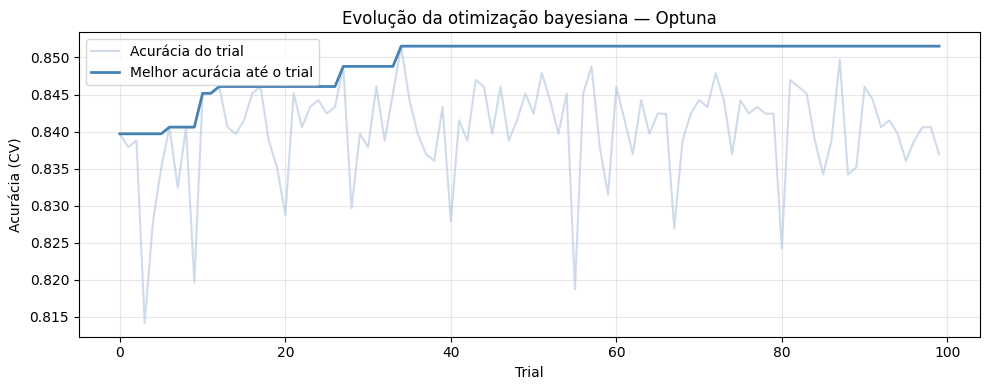

In [23]:
# Visualizando a evolução da otimização ao longo dos trials
# Permite ver se o Optuna convergiu ou ainda havia espaço para melhorar

valores = [t.value for t in study.trials]
melhores = [max(valores[:i+1]) for i in range(len(valores))]

plt.figure(figsize=(10, 4))
plt.plot(valores, color='lightsteelblue', alpha=0.6, label='Acurácia do trial')
plt.plot(melhores, color='steelblue', lw=2, label='Melhor acurácia até o trial')
plt.xlabel('Trial')
plt.ylabel('Acurácia (CV)')
plt.title('Evolução da otimização bayesiana — Optuna')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Lendo o gráfico de evolução:**
- Linha azul clara (cada trial): Acurácia individual de cada combinação testada (a variação é normal), pois o Optuna também explora regiões menos promissoras para não ficar preso em ótimos locais (estratégia explore vs exploit).

- Linha azul (melhor até o trial): Mostra a convergência do processo. Se estabilizou antes do trial 100, significa que mais trials provavelmente não trariam ganho adicional significativo. Se ainda estava subindo no trial 100, valeria aumentar n_trials.


Se a curva azul estabilizou antes do trial 100.
o Optuna convergiu e mais trials não trariam ganho significativo.

In [24]:
# Treinando o modelo final com os melhores hiperparâmetros encontrados
melhor_modelo = XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric='logloss'
)
melhor_modelo.fit(X_balanced_scaled, y_balanced)

y_pred_otimizado = melhor_modelo.predict(X_balanced_scaled)

print('=== XGBoost — Modelo Otimizado (Optuna) ===')
print(classification_report(y_balanced, y_pred_otimizado))

=== XGBoost — Modelo Otimizado (Optuna) ===
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       549
           1       0.96      0.94      0.95       549

    accuracy                           0.95      1098
   macro avg       0.95      0.95      0.95      1098
weighted avg       0.95      0.95      0.95      1098



In [25]:
# Cross-validation do modelo otimizado
cv_scores_otimizado = cross_val_score(
    melhor_modelo, X_balanced_scaled, y_balanced,
    cv=skf, scoring='accuracy'
)

print('Cross-Validation — Modelo Otimizado (Optuna):')
print(f'Scores por fold: {cv_scores_otimizado.round(4)}')
print(f'Média:  {cv_scores_otimizado.mean():.4f}')
print(f'Desvio: {cv_scores_otimizado.std():.4f}')
print()
print(f'Melhora em relação ao baseline: +{(cv_scores_otimizado.mean() - cv_scores_base.mean()):.4f}')

Cross-Validation — Modelo Otimizado (Optuna):
Scores por fold: [0.8409 0.8636 0.8455 0.8219 0.8311]
Média:  0.8406
Desvio: 0.0141

Melhora em relação ao baseline: +0.0000


**Interpretando o cross-validation do modelo otimizado:**
  
  A média dos 5 folds é o número mais confiável do experimento, ela estima a performance real em dados novos, como o teste do Kaggle.

- Desvio padrão baixo (< 0.01): modelo estável e consistente entre os folds.
- Desvio padrão alto (> 0.02): modelo instável. Resultados dependem muito de quais dados caíram em cada fold, sinal de overfitting.

**Compare sempre com o baseline da célula anterior:**
- Se o CV do otimizado for maior, a otimização valeu a pena.
- Se for igual ou menor, os parâmetros padrão já eram suficientes para esses dados.

## 9. Análise de Importância das Features

O XGBoost, assim como o Random Forest, fornece a importância de cada feature.
Isso nos permite validar o feature engineering e se as features novas
(`Title`, `FamilySize`, `IsAlone`, `FarePerPerson`) aparecerem com alta importância,
confirma que elas agregaram valor real ao modelo.

O XGBoost oferece três tipos de importância:
- **weight:** quantas vezes a feature foi usada para dividir um nó
- **gain:** melhoria média de performance trazida pela feature (mais interpretável)
- **cover:** cobertura média de amostras quando a feature é usada

Usamos **gain** por ser a métrica mais significativa para interpretação.

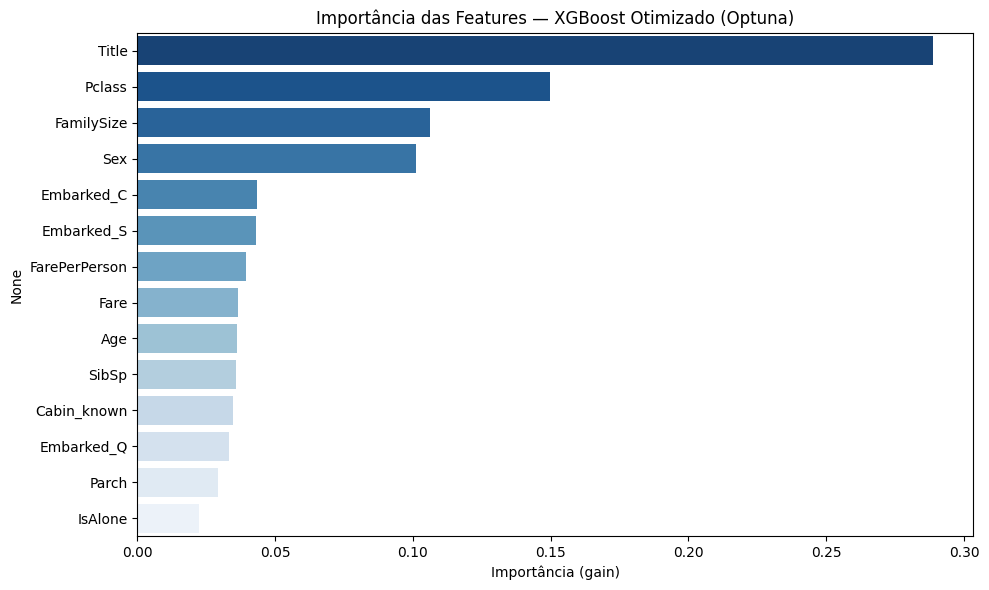

Top 5 features mais importantes:
Title         0.2889
Pclass        0.1498
FamilySize    0.1062
Sex           0.1010
Embarked_C    0.0433
dtype: float32


In [26]:
# Importância das features — gain (melhoria média de performance)
importancias = pd.Series(
    melhor_modelo.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias.values, y=importancias.index, palette='Blues_r')
plt.title('Importância das Features — XGBoost Otimizado (Optuna)')
plt.xlabel('Importância (gain)')
plt.tight_layout()
plt.show()

print('Top 5 features mais importantes:')
print(importancias.head().round(4))

## 10. Matriz de Confusão

A matriz de confusão mostra em detalhe onde o modelo acerta e onde erra:
- **Verdadeiro Positivo (VP):** previu sobreviveu, realmente sobreviveu
- **Verdadeiro Negativo (VN):** previu não sobreviveu, realmente não sobreviveu
- **Falso Positivo (FP):** previu sobreviveu, mas não sobreviveu (erro tipo I)
- **Falso Negativo (FN):** previu não sobreviveu, mas sobreviveu (erro tipo II)

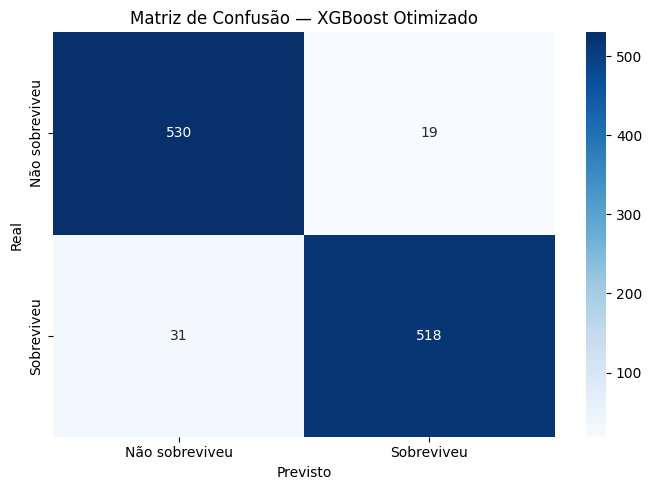

In [27]:
cm = confusion_matrix(y_balanced, y_pred_otimizado)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Não sobreviveu', 'Sobreviveu'],
    yticklabels=['Não sobreviveu', 'Sobreviveu']
)
plt.title('Matriz de Confusão — XGBoost Otimizado')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

## 11. Curva ROC e AUC

A **Curva ROC** é uma das métricas mais usadas em competições do Kaggle.
Ela mostra o trade-off entre sensibilidade (verdadeiros positivos) e
especificidade (falsos positivos) em diferentes limiares de decisão.

O **AUC** resume a curva em um número:
- AUC = 1.0 → modelo perfeito
- AUC = 0.5 → equivalente a chute aleatório
- AUC > 0.8 → modelo considerado bom na prática

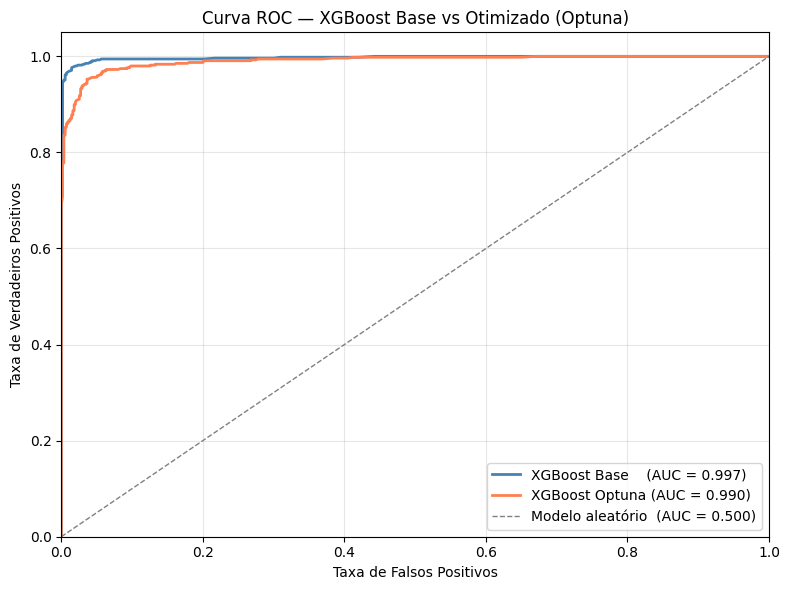

AUC Base:    0.9971
AUC Optuna: 0.9902
Ganho AUC:  +-0.0069


In [28]:
# Calculando curva ROC para base e otimizado
y_prob_base      = xgb_base.predict_proba(X_balanced_scaled)[:, 1]
y_prob_otimizado = melhor_modelo.predict_proba(X_balanced_scaled)[:, 1]

fpr_base, tpr_base, _ = roc_curve(y_balanced, y_prob_base)
fpr_otim, tpr_otim, _ = roc_curve(y_balanced, y_prob_otimizado)

auc_base = roc_auc_score(y_balanced, y_prob_base)
auc_otim = roc_auc_score(y_balanced, y_prob_otimizado)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, color='steelblue', lw=2,
         label=f'XGBoost Base    (AUC = {auc_base:.3f})')
plt.plot(fpr_otim, tpr_otim, color='coral', lw=2,
         label=f'XGBoost Optuna (AUC = {auc_otim:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--',
         label='Modelo aleatório  (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC — XGBoost Base vs Otimizado (Optuna)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC Base:    {auc_base:.4f}')
print(f'AUC Optuna: {auc_otim:.4f}')
print(f'Ganho AUC:  +{(auc_otim - auc_base):.4f}')

## 12. Comparativo: Base vs Otimizado

O comparativo abaixo responde a pergunta central do experimento:
**a otimização bayesiana com Optuna trouxe ganho real?**

Usamos a **média do cross-validation** (não a acurácia no treino)
pois a acurácia no treino sempre será alta (o modelo viu esses dados).
O CV estima como o modelo se comportará em dados novos, como o teste do Kaggle.

O **desvio padrão entre os folds** também importa: valores baixos indicam
que o modelo é consistente independentemente de quais dados ele treina.

In [29]:
print('=' * 55)
print('COMPARATIVO FINAL — XGBoost Base vs Optuna')
print('=' * 55)
print(f'Baseline (parâmetros padrão):')
print(f'  CV Accuracy: {cv_scores_base.mean():.4f} (± {cv_scores_base.std():.4f})')
print(f'  AUC:         {auc_base:.4f}')
print()
print(f'Otimizado (Optuna — 100 trials):')
print(f'  CV Accuracy: {cv_scores_otimizado.mean():.4f} (± {cv_scores_otimizado.std():.4f})')
print(f'  AUC:         {auc_otim:.4f}')
print()
print(f'Ganho Accuracy: +{(cv_scores_otimizado.mean() - cv_scores_base.mean()) * 100:.2f} p.p.')
print(f'Ganho AUC:      +{(auc_otim - auc_base):.4f}')
print('=' * 55)

COMPARATIVO FINAL — XGBoost Base vs Optuna
Baseline (parâmetros padrão):
  CV Accuracy: 0.8406 (± 0.0193)
  AUC:         0.9971

Otimizado (Optuna — 100 trials):
  CV Accuracy: 0.8406 (± 0.0141)
  AUC:         0.9902

Ganho Accuracy: +0.00 p.p.
Ganho AUC:      +-0.0069


## 13. Geração das Previsões para o Kaggle

Utilizamos o modelo otimizado pelo Optuna para gerar as previsões finais.
O arquivo gerado segue o formato exigido pela competição:
duas colunas — `PassengerId` e `Survived`.

In [30]:
# Gerando previsões finais
y_pred_kaggle = melhor_modelo.predict(X_test_scaled)

print(f'Previsões geradas: {len(y_pred_kaggle)}')
print(f'Distribuição das previsões:')
print(pd.Series(y_pred_kaggle).value_counts())
print(f'Taxa prevista de sobrevivência: {y_pred_kaggle.mean():.2%}')

Previsões geradas: 418
Distribuição das previsões:
0    252
1    166
Name: count, dtype: int64
Taxa prevista de sobrevivência: 39.71%


In [31]:
# Gerando previsões do modelo BASE (sem otimização)
y_pred_base_kaggle = xgb_base.predict(X_test_scaled)

submissao_base = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived':    y_pred_base_kaggle
})

submissao_base.to_csv('submission_xgboost_base.csv', index=False)

print('Arquivo gerado: submission_xgboost_base.csv')
print(f'Taxa prevista de sobrevivência (base): {y_pred_base_kaggle.mean():.2%}')

Arquivo gerado: submission_xgboost_base.csv
Taxa prevista de sobrevivência (base): 40.43%


In [32]:
# Gerando previsões do modelo OTIMIZADO (Optuna)
y_pred_kaggle = melhor_modelo.predict(X_test_scaled)

submissao_otimizado = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived':    y_pred_kaggle
})

submissao_otimizado.to_csv('submission_xgboost_optuna.csv', index=False)

print('Arquivo gerado: submission_xgboost_optuna.csv')
print(f'Taxa prevista de sobrevivência (otimizado): {y_pred_kaggle.mean():.2%}')
print()
print('--- Comparativo das previsões ---')
print(f'Base:      {y_pred_base_kaggle.sum()} sobreviventes previstos de {len(y_pred_base_kaggle)}')
print(f'Otimizado: {y_pred_kaggle.sum()} sobreviventes previstos de {len(y_pred_kaggle)}')
print()
print('Submeta os dois no Kaggle e compare os scores!')
print('  submission_xgboost_base.csv    → score do modelo sem otimização')
print('  submission_xgboost_optuna.csv  → score do modelo com Optuna')
print()
print('A diferença entre os dois scores é o ganho real da otimização bayesiana.')

Arquivo gerado: submission_xgboost_optuna.csv
Taxa prevista de sobrevivência (otimizado): 39.71%

--- Comparativo das previsões ---
Base:      169 sobreviventes previstos de 418
Otimizado: 166 sobreviventes previstos de 418

Submeta os dois no Kaggle e compare os scores!
  submission_xgboost_base.csv    → score do modelo sem otimização
  submission_xgboost_optuna.csv  → score do modelo com Optuna

A diferença entre os dois scores é o ganho real da otimização bayesiana.


## 14. Conclusão e Análise Crítica

### O que foi feito de diferente em relação à aula

| Aspecto | Aula (M41) | Este notebook |
|---|---|---|
| Modelo | SVM / XGBoost | XGBoost |
| Otimização | GridSearchCV | Optuna — otimização bayesiana |
| Nº de hiperparâmetros explorados | 5 | 9 |
| Estratégia de busca | Grade fixa | Aprendizado por tentativas |
| Análise exploratória | Não realizada | EDA completa com 5 gráficos |
| Nº de features | 4 | 14 |
| Feature engineering | Nenhum | Title, FamilySize, IsAlone, FarePerPerson |
| Imputação de Age | Média global | Mediana por Pclass + Sex |
| Cross-validation | KFold padrão | StratifiedKFold (5 folds) |
| Métricas apresentadas | Accuracy + report | + Curva ROC, AUC, evolução Optuna |

---

### O que funcionou bem

O **Optuna** foi a principal aposta e ela se justifica: ao contrário do GridSearchCV
que testa combinações fixas, a otimização bayesiana direciona os trials para regiões
promissoras do espaço de hiperparâmetros. Com 9 parâmetros explorados, o espaço de
busca é praticamente infinito, o Grid não conseguiria cobrir isso de forma viável.

O **feature engineering** continuou sendo o maior diferencial isolado.
O `Title` captura em uma única feature gênero, faixa etária e status social,
sendo mais informativo do que `Sex` isolado. O `FamilySize` captura o que
SibSp e Parch isolados não conseguem — o padrão familiar completo.

---